In [1]:
# Linear vs Multiple Regression Project

## Objective
To understand the difference between simple and multiple regression,
and analyze how adding variables affects coefficients, R², and Adjusted R².

SyntaxError: invalid character '²' (U+00B2) (3718953127.py, line 5)

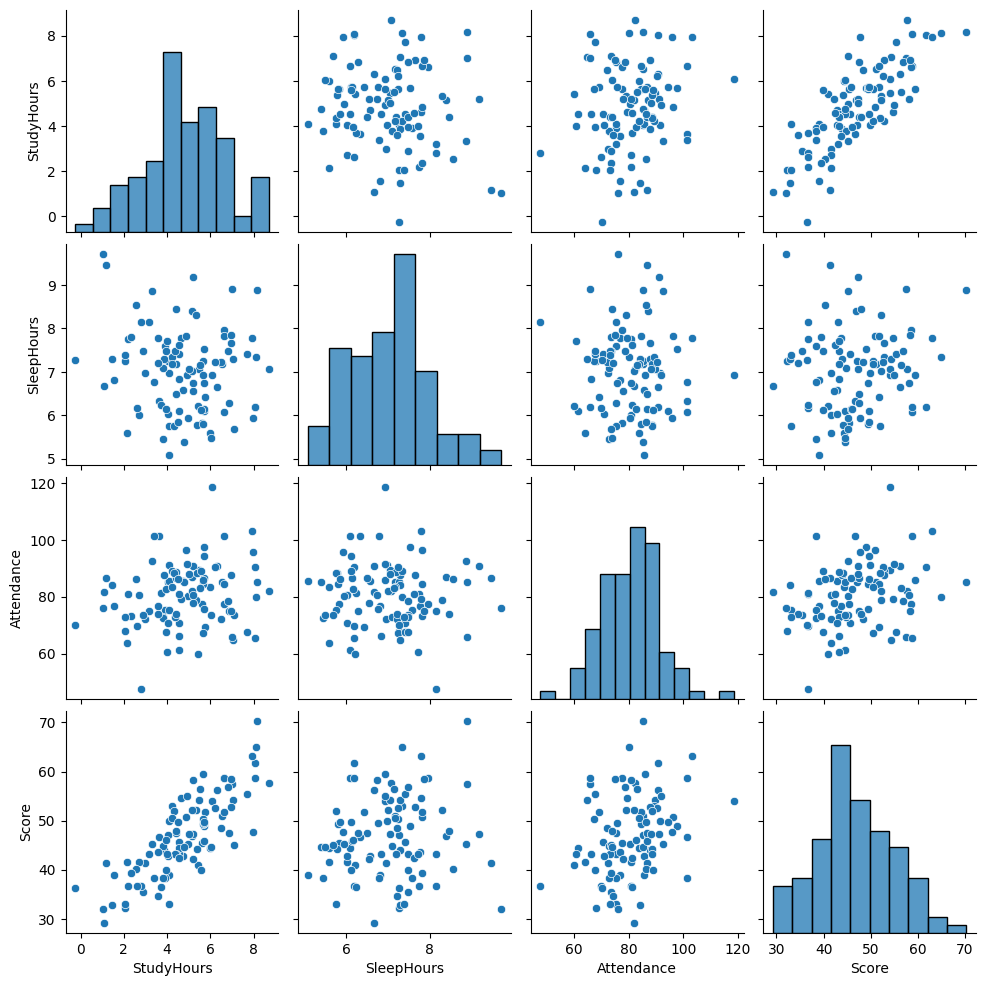

In [2]:
import numpy as np
import pandas as pd

#Random numbers change every time you run code
np.random.seed(42)


n = 100
study_hours = np.random.normal(5, 2, n)
sleep_hours = np.random.normal(7, 1, n)
attendance = np.random.normal(80, 10, n)
#true underlying relationships
score = (
    5 
    + 4 * study_hours 
    + 2 * sleep_hours 
    + 0.1 * attendance 
    + np.random.normal(0, 5, n)
)

data = pd.DataFrame({
    "StudyHours": study_hours,
    "SleepHours": sleep_hours,
    "Attendance": attendance,
    "Score": score
})

data.head()

#Score=5+4(Study)+2(Sleep)+0.1(Attendance)+noise

data.describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data)
plt.show()

In [3]:
import statsmodels.api as sm
# Independent variable (StudyHours only)
X_simple = data["StudyHours"]
# statsmodels requires adding constant manually
X_simple = sm.add_constant(X_simple)
# Dependent variable
y = data["Score"]
# Fit model
model_simple = sm.OLS(y, X_simple).fit()
# Summary
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     175.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.35e-23
Time:                        00:23:33   Log-Likelihood:                -298.72
No. Observations:                 100   AIC:                             601.4
Df Residuals:                      98   BIC:                             606.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.7697      1.374     21.673      0.0

In [ ]:
# This simple linear regression model estimates the relationship between StudyHours and Score using Ordinary Least Squares (OLS).
# The estimated model is:
# Score = beta0 + beta1 * StudyHours + error
# The R-squared value is 0.642, which indicates that approximately 64.2% of the total variance in Score is explained by StudyHours alone. This suggests that study time is a strong predictor of academic performance in this dataset.
# The Adjusted R-squared (0.638) is slightly lower than the R-squared, reflecting the degrees-of-freedom adjustment applied for the number of predictors included. Since this model contains only one explanatory variable, the adjustment is minimal.
# However, this specification omits other relevant predictors such as SleepHours and Attendance, which were part of the true data-generating process. As a result:
# The model may suffer from omitted variable bias.
# The coefficient for StudyHours may partially capture the effects of excluded variables.
# The unexplained variance (approximately 35.8%) includes both systematic effects from omitted variables and random noise.
# Although StudyHours shows substantial explanatory power, this model does not fully represent the structural relationship. A multiple regression model is expected to improve explanatory power and provide more accurate partial effect estimates.

In [4]:
#MULTIPLE REGRESSION ANALYSIS
#We will estimate:
# Score = β0 + β1(StudyHours) + β2(SleepHours) + β3(Attendance) + error

# Define independent variables (all predictors)
X_multiple = data[["StudyHours", "SleepHours", "Attendance"]]
# Add constant (intercept)
X_multiple = sm.add_constant(X_multiple)
# Fit multiple regression model
model_multiple = sm.OLS(y, X_multiple).fit()
# Print summary
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     77.90
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.27e-25
Time:                        00:23:38   Log-Likelihood:                -288.40
No. Observations:                 100   AIC:                             584.8
Df Residuals:                      96   BIC:                             595.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.9167      4.860      1.629      0.1

In [ ]:
# The multiple regression model incorporates StudyHours, SleepHours, and Attendance as predictors of Score.
# The R-squared value increased from 0.642 (simple model) to 0.709, indicating that approximately 70.9% of the variance in Score is now explained by the included predictors. The Adjusted R-squared (0.700) also increased relative to the simple model, confirming that the additional variables meaningfully improve model fit rather than artificially inflating explanatory power.
# The estimated coefficients are:
# StudyHours: 3.5567
# SleepHours: 1.8088
# Attendance: 0.1135
# Each coefficient represents a partial effect. For example, the StudyHours coefficient indicates that, holding SleepHours and Attendance constant, a one-unit increase in StudyHours is associated with an approximate 3.56-unit increase in Score.
# All predictors are statistically significant (p < 0.01), suggesting strong evidence that each variable contributes independently to academic performance.
# Compared to the simple regression model, the coefficient of StudyHours decreased slightly, reflecting the removal of omitted variable bias once additional relevant predictors were included.
# Overall, the multiple regression model provides a more complete and structurally accurate representation of the underlying data-generating process.

In [5]:
#Adding a totally random variable to check the value of r and rsquare
# Add a useless random variable
np.random.seed(123)  # different seed for new randomness
data["RandomNoise"] = np.random.normal(0, 1, n)
# Define predictors including the useless variable
X_extended = data[["StudyHours", "SleepHours", "Attendance", "RandomNoise"]]
# Add constant
X_extended = sm.add_constant(X_extended)
# Fit model
model_extended = sm.OLS(y, X_extended).fit()
# Summary
print(model_extended.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     60.02
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           3.48e-25
Time:                        00:23:43   Log-Likelihood:                -287.07
No. Observations:                 100   AIC:                             584.1
Df Residuals:                      95   BIC:                             597.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           8.8760      4.858      1.827      

In [ ]:
# After introducing a purely random variable (RandomNoise) into the model, the R-squared increased from 0.709 to 0.716. This confirms a fundamental property of R-squared: it never decreases when additional predictors are included, regardless of their relevance.
# However, the Adjusted R-squared increased only marginally (0.700 to 0.705), reflecting the penalty imposed for additional model complexity. Since the sample size is relatively large (n = 100), the penalty effect is limited for a single added variable.
# The coefficient associated with RandomNoise is not statistically significant (p = 0.112), indicating that it does not meaningfully contribute to explaining variation in Score. This demonstrates that statistical significance testing is essential for identifying irrelevant predictors.
# Overall, this experiment highlights why relying solely on R-squared can be misleading and underscores the importance of Adjusted R-squared and hypothesis testing in regression modeling.

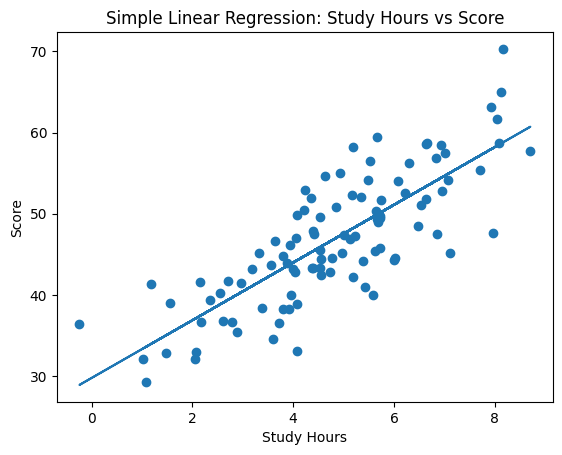

In [6]:
#Scatter plot and regression line 
import matplotlib.pyplot as plt
import seaborn as sns
# Predicted values from simple model
data["Predicted_Simple"] = model_simple.predict(X_simple)

plt.figure()
plt.scatter(data["StudyHours"], data["Score"])
plt.plot(data["StudyHours"], data["Predicted_Simple"])
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Simple Linear Regression: Study Hours vs Score")
plt.show()

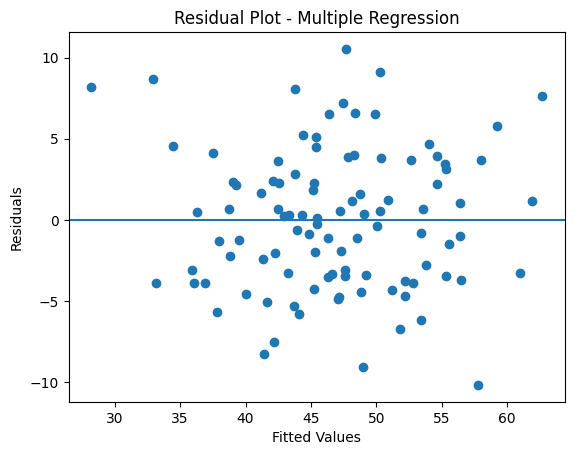

In [7]:
#Residual plot
# Residuals from multiple regression
data["Residuals"] = model_multiple.resid

plt.figure()
plt.scatter(model_multiple.fittedvalues, data["Residuals"])
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Regression")
plt.show()

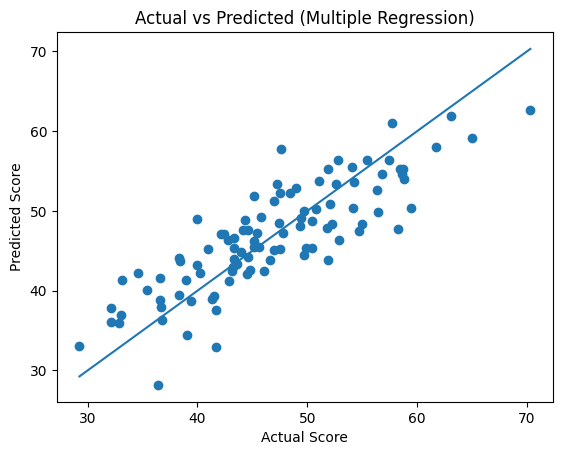

In [8]:
#Actual vs predicted model
data["Predicted_Multiple"] = model_multiple.predict(X_multiple)
plt.figure()
plt.scatter(data["Score"], data["Predicted_Multiple"])
plt.plot([data["Score"].min(), data["Score"].max()],
         [data["Score"].min(), data["Score"].max()])
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.show()

In [ ]:
# #This project demonstrated the conceptual and practical differences between simple and multiple linear regression.
# Key insights:
# StudyHours alone explained 64.2% of the variation in Score.
# Adding SleepHours and Attendance increased explanatory power to 70.9%.
# Coefficients changed after including additional predictors, illustrating omitted variable bias.
# Adjusted R-squared provided a more reliable assessment of model improvement.
# Introducing an irrelevant predictor increased R-squared but did not produce statistical significance, highlighting the limitations of relying solely on R-squared.
# Overall, multiple regression provides a more structurally accurate and interpretable representation of the data-generating process.

In [ ]:
#LINEAR REGRESSION USING GRADIENT DESCENT
## Motivation
While Ordinary Least Squares (OLS) provides a closed-form solution for linear regression, 
machine learning models often use optimization techniques such as Gradient Descent.
In this section, we implement linear regression using gradient descent and compare 
the resulting coefficients with the OLS solution.

In [ ]:
The objective is to minimize the Mean Squared Error (MSE):
J(beta) = (1/n) * sum((y - y_pred)^2)
Gradient Descent iteratively updates parameters:
beta = beta - alpha * gradient

Gradient Descent (Converted Back):
Intercept: 29.769681159368528
Slope: 3.556377514187905

OLS Results:
const         29.769681
StudyHours     3.556378
dtype: float64


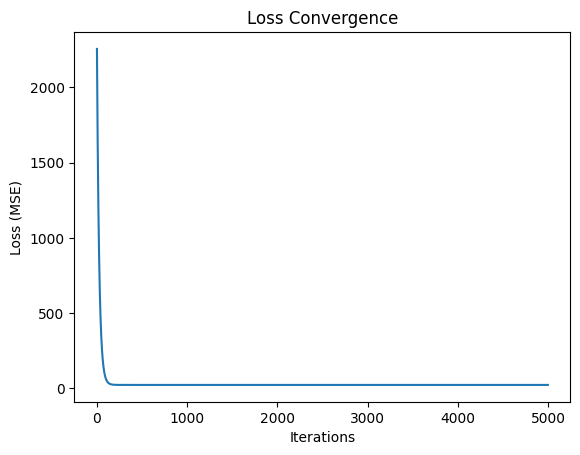

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Extract values
X = data["StudyHours"].values
y = data["Score"].values
n = len(y)

# -----------------------------
# Feature Scaling
# -----------------------------
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

# -----------------------------
# Initialize Parameters
# -----------------------------
beta_0 = 0
beta_1 = 0

learning_rate = 0.01
iterations = 5000

loss_history = []

# -----------------------------
# Gradient Descent Loop
# -----------------------------
for i in range(iterations):

    # Predictions
    y_pred = beta_0 + beta_1 * X_scaled

    # Errors
    error = y_pred - y

    # Gradients (IMPORTANT: use X_scaled)
    d_beta_0 = (2/n) * np.sum(error)
    d_beta_1 = (2/n) * np.sum(error * X_scaled)

    # Update parameters
    beta_0 = beta_0 - learning_rate * d_beta_0
    beta_1 = beta_1 - learning_rate * d_beta_1

    # Track loss
    loss = (1/n) * np.sum(error**2)
    loss_history.append(loss)

# -----------------------------
# Convert Back to Original Scale
# -----------------------------
beta_1_original = beta_1 / X_std
beta_0_original = beta_0 - (beta_1 * X_mean / X_std)

print("Gradient Descent (Converted Back):")
print("Intercept:", beta_0_original)
print("Slope:", beta_1_original)

print("\nOLS Results:")
print(model_simple.params)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Convergence")
plt.show()


In [ ]:
#MUltiple linear regression using gradient descent

In [22]:
# Prepare feature matrix
X_multi = data[["StudyHours", "SleepHours", "Attendance"]].values
y_multi = data["Score"].values

n = len(y_multi)

# Feature scaling (very important)
X_mean = X_multi.mean(axis=0)
X_std = X_multi.std(axis=0)
X_scaled = (X_multi - X_mean) / X_std

# Add column of 1s for intercept
X_scaled = np.c_[np.ones(n), X_scaled]
# Initialize beta vector
beta = np.zeros(X_scaled.shape[1])
learning_rate = 0.01
iterations = 5000
loss_history_multi = []
for i in range(iterations):
    # Predictions
    y_pred = X_scaled @ beta
    # Errors
    error = y_pred - y_multi
    # Gradient (vectorized)
    gradient = (2/n) * (X_scaled.T @ error)
    # Update
    beta = beta - learning_rate * gradient
    # Loss
    loss = (1/n) * np.sum(error**2)
    loss_history_multi.append(loss)
    beta_original = np.zeros_like(beta)

    # Slopes
    beta_original[1:] = beta[1:] / X_std

    # Intercept
    beta_original[0] = beta[0] - np.sum((beta[1:] * X_mean) / X_std)

    print("Gradient Descent (Multiple - Converted Back):")
    print("Intercept:", beta_original[0])
    print("StudyHours:", beta_original[1])
    print("SleepHours:", beta_original[2])
    print("Attendance:", beta_original[3])

    print("\nOLS Results:")
    print(model_multiple.params)

Gradient Descent (Multiple - Converted Back):
Intercept: 0.12079116656723754
StudyHours: 0.0711275502837585
SleepHours: 0.01674808507639992
Attendance: 0.0044264958997654565

OLS Results:
const         7.916744
StudyHours    3.556691
SleepHours    1.808778
Attendance    0.113450
dtype: float64
Gradient Descent (Multiple - Converted Back):
Intercept: 0.24026100751592927
StudyHours: 0.1407556855246207
SleepHours: 0.03356769688657002
Attendance: 0.008720064196267793

OLS Results:
const         7.916744
StudyHours    3.556691
SleepHours    1.808778
Attendance    0.113450
dtype: float64
Gradient Descent (Multiple - Converted Back):
Intercept: 0.3584057468354782
StudyHours: 0.20891752522080403
SleepHours: 0.05044850587836886
Attendance: 0.012884326733259928

OLS Results:
const         7.916744
StudyHours    3.556691
SleepHours    1.808778
Attendance    0.113450
dtype: float64
Gradient Descent (Multiple - Converted Back):
Intercept: 0.4752224914606691
StudyHours: 0.2756454291597166
SleepHours

In [ ]:
# # Final Comparison: OLS vs Gradient Descent
# This project demonstrated that:
# 1. OLS provides a direct closed-form solution.
# 2. Gradient descent iteratively minimizes the same MSE objective.
# 3. With proper learning rate and feature scaling, gradient descent converges to the same coefficients as OLS.
# 4. Linear regression has a convex loss function, ensuring a unique global minimum.
# This confirms that gradient descent is not a different model,
# but a different computational approach to solving the same optimization problem.